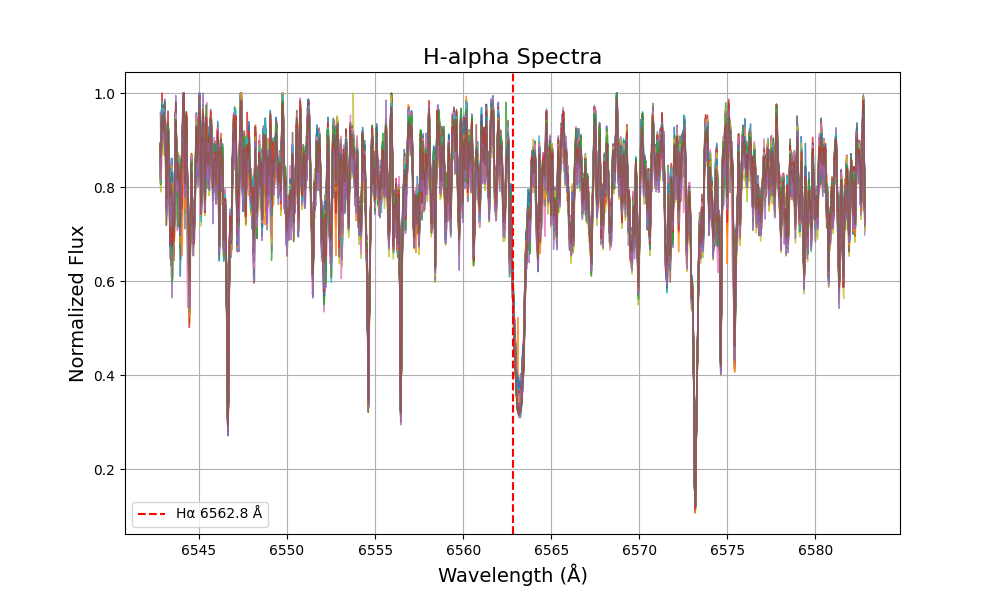

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Folder path
directory = '/Users/abishaj/Documents/Hoststars_Activity/M_stars/GJ_433'

%matplotlib widget 

# Get all FITS files
fits_files = [os.path.join(directory, f) for f in os.listdir(directory) if f.endswith('.fits')]

# H-alpha parameters
h_alpha_center = 6562.8
zoom_window = 20  # Å

plt.figure(figsize=(10, 6))

for path in sorted(fits_files):
    try:
        with fits.open(path) as hdul:
            hdr = hdul[0].header
            data = hdul[1].data

            # --- Get observation time ---
            mjd = hdr.get("MJD-OBS", np.nan)

            # --- Handle BOTH formats safely ---
            colnames = data.columns.names

            if "wavelength_air" in colnames:
                wave = data["wavelength_air"]
                flux = data["flux"]

            elif "WAVE" in colnames:
                wave = data["WAVE"]
                flux = data["FLUX"]

                # Handle 2D case
                if wave.ndim > 1:
                    wave = wave[0]
                    flux = flux[0]
            else:
                print(f"Skipping {path} (no valid columns)")
                continue

            # --- Select H-alpha region ---
            mask = (wave >= h_alpha_center - zoom_window) & \
                   (wave <= h_alpha_center + zoom_window)

            wave_zoom = wave[mask]
            flux_zoom = flux[mask]

            # --- Normalize ---
            if len(flux_zoom) > 0:
                flux_zoom = flux_zoom / np.max(flux_zoom)

                # Plot (you can label with MJD if needed)
                plt.plot(wave_zoom, flux_zoom, lw=1, alpha=0.8)

    except Exception as e:
        print(f"Error reading file {path}: {e}")

# Reference line
plt.axvline(x=h_alpha_center, color='red', linestyle='--', label='Hα 6562.8 Å')

plt.xlabel("Wavelength (Å)", fontsize=14)
plt.ylabel("Normalized Flux", fontsize=14)
plt.title("H-alpha Spectra", fontsize=16)
plt.grid(True)
plt.legend()
plt.show()

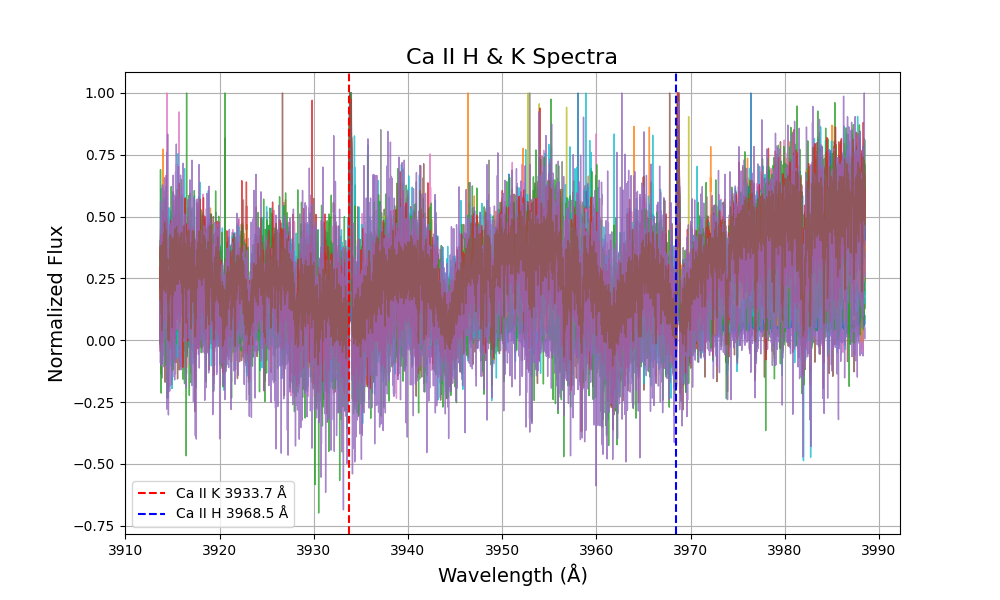

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Folder path
directory = '/Users/abishaj/Documents/Hoststars_Activity/M_stars/GJ_433'

%matplotlib widget 

# Get all FITS files
fits_files = [os.path.join(directory, f) for f in os.listdir(directory) if f.endswith('.fits')]

# Ca II H & K parameters
ca_k_center = 3933.7
ca_h_center = 3968.5
zoom_window = 20  # Å

plt.figure(figsize=(10, 6))

for path in sorted(fits_files):
    try:
        with fits.open(path) as hdul:
            hdr = hdul[0].header
            data = hdul[1].data

            # --- Get observation time ---
            mjd = hdr.get("MJD-OBS", np.nan)

            # --- Handle BOTH formats safely ---
            colnames = data.columns.names

            if "wavelength_air" in colnames:
                wave = data["wavelength_air"]
                flux = data["flux"]

            elif "WAVE" in colnames:
                wave = data["WAVE"]
                flux = data["FLUX"]

                # Handle 2D case
                if wave.ndim > 1:
                    wave = wave[0]
                    flux = flux[0]
            else:
                print(f"Skipping {path} (no valid columns)")
                continue

            # --- Select Ca II H & K region ---
            mask = (wave >= (ca_k_center - zoom_window)) & \
                   (wave <= (ca_h_center + zoom_window))

            wave_zoom = wave[mask]
            flux_zoom = flux[mask]

            # --- Normalize ---
            if len(flux_zoom) > 0:
                flux_zoom = flux_zoom / np.max(flux_zoom)

                # Plot
                plt.plot(wave_zoom, flux_zoom, lw=1, alpha=0.8)

    except Exception as e:
        print(f"Error reading file {path}: {e}")

# --- Reference lines ---
plt.axvline(x=ca_k_center, color='red', linestyle='--', label='Ca II K 3933.7 Å')
plt.axvline(x=ca_h_center, color='blue', linestyle='--', label='Ca II H 3968.5 Å')

plt.xlabel("Wavelength (Å)", fontsize=14)
plt.ylabel("Normalized Flux", fontsize=14)
plt.title("Ca II H & K Spectra", fontsize=16)
plt.grid(True)
plt.legend()
plt.show()

In [2]:
!pip install ipympl

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 1.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 1.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [ipympl]2m3/4 [ipympl]

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


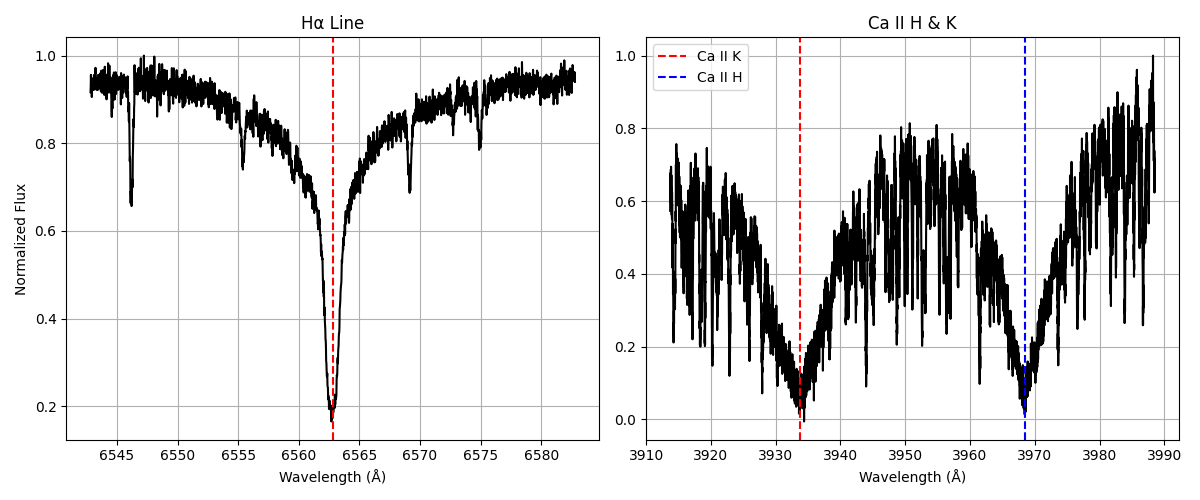

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# --- Give your FITS file path ---
file_path = '/Volumes/TOSHIBA EXT/stars/Hoststars_Activity/F_stars/HD_103774/r.HARPS.2004-12-21T08:06:39.477_S1D_A.fits'

%matplotlib widget 

# Line centers
h_alpha = 6562.8
ca_k = 3933.7
ca_h = 3968.5
zoom = 20  # Å

with fits.open(file_path) as hdul:
    data = hdul[1].data

    # --- Handle both formats ---
    colnames = data.columns.names

    if "wavelength_air" in colnames:
        wave = data["wavelength_air"]
        flux = data["flux"]

    elif "WAVE" in colnames:
        wave = data["WAVE"]
        flux = data["FLUX"]

        if wave.ndim > 1:
            wave = wave[0]
            flux = flux[0]
    else:
        raise ValueError("No valid wavelength column found")

# --- Create figure ---
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# ===== H-alpha =====
mask_ha = (wave >= h_alpha - zoom) & (wave <= h_alpha + zoom)
wave_ha = wave[mask_ha]
flux_ha = flux[mask_ha]

flux_ha = flux_ha / np.max(flux_ha)

axs[0].plot(wave_ha, flux_ha, color='black')
axs[0].axvline(h_alpha, color='red', linestyle='--')
axs[0].set_title("Hα Line")
axs[0].set_xlabel("Wavelength (Å)")
axs[0].set_ylabel("Normalized Flux")
axs[0].grid(True)

# ===== Ca II H & K =====
mask_ca = (wave >= ca_k - zoom) & (wave <= ca_h + zoom)
wave_ca = wave[mask_ca]
flux_ca = flux[mask_ca]

flux_ca = flux_ca / np.max(flux_ca)

axs[1].plot(wave_ca, flux_ca, color='black')
axs[1].axvline(ca_k, color='red', linestyle='--', label='Ca II K')
axs[1].axvline(ca_h, color='blue', linestyle='--', label='Ca II H')
axs[1].set_title("Ca II H & K")
axs[1].set_xlabel("Wavelength (Å)")
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()

In [71]:
from astropy.io import fits

hdul = fits.open("/Users/abishaj/Documents/Hoststars_Activity/G_stars/HD_89567/ADP.2014-09-16T11:03:33.303.fits")
hdul.info()
print(hdul[0].header)

Filename: /Users/abishaj/Documents/Hoststars_Activity/G_stars/HD_89567/ADP.2014-09-16T11:03:33.303.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU    3049   ()      
  1  SPECTRUM      1 BinTableHDU     45   1R x 3C   [313138D, 313138E, 313138E]   
SIMPLE  =                    T / file does conform to FITS standard             BITPIX  =                    8 / number of bits per data pixel                  NAXIS   =                    0 / number of data axes                            EXTEND  =                    T / FITS dataset may contain extensions            DATASUM = '0       '           / data unit checksum updated 2014-09-11T16:45:22 COMMENT FITS (Flexible Image Transport System) format is defined in 'Astronomy  COMMENT and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H   DATE    = '2010-08-04T03:09:28.674' / Date this file was written                INSTRUME= 'HARPS   '           / Instrument used            

In [6]:
!pip install ipympl

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [7]:
!jupyter nbextension enable --py widgetsnbextension

usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

optional arguments:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: kernel kernelspec migrate run troubleshoot

Jupyter command `jupyter-nbextension` not found.
